In [1]:
%matplotlib inline
%reload_ext autoreload
%autoreload 2

In [2]:
import sys

sys.path.append('../scripts')

In [23]:
import numpy as np
import scanpy as sc
import pickle
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from tqdm.auto import tqdm

from cellina import CellinaModel
from utils import set_seed, plot_results, evaluate_models

In [4]:
import cellina
cellina.__version__

'0.7.1'

In [34]:
plt.rcParams['font.family'] = 'monospace'

# Get dataset

In [5]:
set_seed(0)

In [6]:
base_path = "/data2/a330d/datasets/crc/raw_zenodo"
sid = "242"
adata = sc.read(f"{base_path}/crc_{sid}.h5ad")

In [7]:
labels_key = "coarse_type"
domains_key = "typ_clean"
batch_key = "sid"

In [8]:
from train_loo import preprocess_adata

adata = preprocess_adata(adata, 
                n_top_genes=3000, 
                n_neighbors=200,
                labels_key=labels_key,
                domains_key=domains_key,
                )

/data/a330d/miniforge3/envs/cellina-graph/lib/python3.10/site-packages/scanpy/preprocessing/_simple.py:174: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs["n_counts"] = number


In [9]:
split = "random"

# Get holdout indices
if split == "random":
    fraction = 0.1
    n_cells = adata.n_obs
    n_holdout = int(n_cells * fraction)

    # Randomly choose cells
    test_idx = np.random.choice(n_cells, n_holdout, replace=False)

elif split == "ood":
    # Conditions
    is_fibro  = adata.obs["cell_type"].isin(["Fibroblast"])
    is_stress = adata.obs["region"] == "stressed"

    # Combine for test set
    test_mask = (is_stress) & (is_fibro)
    test_idx = np.where(test_mask)[0]
else:
    raise ValueError(f"Unknown split: {split}")

# Get train/val indices
all_idx = np.arange(adata.n_obs)
trainval_idx = np.setdiff1d(all_idx, test_idx)

In [10]:
# Set 'is_holdout' to False by default, then True for selected cells
adata.obs['is_holdout'] = False
adata.obs.iloc[test_idx, adata.obs.columns.get_loc('is_holdout')] = True

In [11]:
from sklearn.model_selection import train_test_split

validation_size = 0.1
train_idx, val_idx = train_test_split(
    trainval_idx,
    test_size=validation_size,
    random_state=0,
    shuffle=True,
)

In [12]:
CellinaModel.setup_anndata(adata,
                           batch_key=batch_key,
                           labels_key=labels_key,
                           domains_key=domains_key,
                           spatial_obsm_key="spatial_x",
                           layer='counts')

INFO     Generating sequential column names                                                                        


/data/a330d/miniforge3/envs/cellina-graph/lib/python3.10/site-packages/scvi/data/fields/_layer_field.py:115: UserWarning: Training will be faster when sparse matrix is formatted as CSR. It is safe to cast before model initialization.
  _verify_and_correct_data_format(adata, self.attr_name, self.attr_key)


In [13]:
base_path = "/data2/a330d/data/cellina-reproducibility/ablations"

In [14]:
batch_size = 4096
max_epochs = 100
n_mc_samples = 500

In [15]:
model_args = {
    # Do not include adata here; train_loo will pass the AnnData when constructing the model
    "n_latent": 64,
    "use_observed_lib_size": True,
    "condition_on_intrinsic": False,
    "classifier_lambda": 1.,
    "discriminator_lambda": 1.,
    "gene_likelihood": "nb",
    "n_layers": 3,
}

train_args = {
    "max_epochs": max_epochs,
    "batch_size": batch_size,
    "check_val_every_n_epoch": 1,
    "early_stopping": True,
    "early_stopping_patience": 25,
    "early_stopping_monitor": "vae_loss_validation",
    "enable_checkpointing": True,
    "devices": [0],
    
}

# Additional plan kwargs sometimes passed to model.train; include a reasonable default
plan_kwargs = {
    "lr": 1e-4,
    "normalize_losses": True,
}

# 1. Classifier

In [17]:
seeds = range(3)
lambda_ys = [0, 1e-9, 1e-7, 1e-3, 1, 10, 100]

## Train

In [ ]:
for lambda_ in tqdm(lambda_ys, desc="Training (lambda_y)"):
    model_args["discriminator_lambda"] = 1e-7
    # Add split info
    train_args['datasplitter_kwargs'] = {
                "external_indexing": [train_idx, val_idx, test_idx],
                }
    for seed in seeds:
        set_seed(seed)
        model_args["classifier_lambda"] = lambda_
        model = CellinaModel(adata, **model_args)
        model.train(**train_args, plan_kwargs=plan_kwargs)
        model.save(f"{base_path}/trained/lambda_y_{lambda_}_seed_{seed}", overwrite=True)

Training (lambda_y):   0%|          | 0/7 [00:00<?, ?it/s]

INFO     cellina: The Cellina model has been initialized with adversarial domain forgetting                        


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
You are using a CUDA device ('NVIDIA GeForce RTX 4090') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
/data/a330d/miniforge3/envs/cellina-base/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=63` in the `DataLoader` to improve performance.
/data/a330d/miniforge3/envs/cellina-base/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers wh

Epoch 100/100: 100%|██████████| 100/100 [39:52<00:00, 23.98s/it, v_num=1, train_loss=610]

`Trainer.fit` stopped: `max_epochs=100` reached.


...

Epoch 44/100:  44%|████▍     | 44/100 [16:23<20:51, 22.34s/it, v_num=1, train_loss=1.96e+3]
Monitored metric vae_loss_validation did not improve in the last 25 records. Best score: 633.360. Signaling Trainer to stop.
INFO     cellina: The Cellina model has been initialized with adversarial domain forgetting                        


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
/data/a330d/miniforge3/envs/cellina-base/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=63` in the `DataLoader` to improve performance.
/data/a330d/miniforge3/envs/cellina-base/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=63` in the `DataLoader` to improve performance.


Epoch 48/100:  48%|████▊     | 48/100 [18:05<19:35, 22.61s/it, v_num=1, train_loss=1.76e+3]
Monitored metric vae_loss_validation did not improve in the last 25 records. Best score: 632.966. Signaling Trainer to stop.
INFO     cellina: The Cellina model has been initialized with adversarial domain forgetting                        


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
/data/a330d/miniforge3/envs/cellina-base/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=63` in the `DataLoader` to improve performance.
/data/a330d/miniforge3/envs/cellina-base/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=63` in the `DataLoader` to improve performance.


Epoch 46/100:  45%|████▌     | 45/100 [16:04<19:07, 20.86s/it, v_num=1, train_loss=1.84e+3]

## Eval

In [18]:
target_col = labels_key
df_lambda_y = evaluate_models(
    adata,
    seeds,
    lambda_type="lambda_y",
    lambda_values=lambda_ys,
    target_col=target_col,
    root_dir=f"{base_path}/trained",
    batch_size=batch_size,
)

Evaluating (lambda_y):   0%|          | 0/7 [00:00<?, ?it/s]Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.


INFO     File /data2/a330d/data/cellina-reproducibility/ablations/trained/lambda_y_0_seed_0/model.pt already       
         downloaded                                                                                                


/data/a330d/miniforge3/envs/cellina-graph/lib/python3.10/site-packages/scvi/data/fields/_layer_field.py:115: UserWarning: Training will be faster when sparse matrix is formatted as CSR. It is safe to cast before model initialization.
  _verify_and_correct_data_format(adata, self.attr_name, self.attr_key)


INFO     cellina: The Cellina model has been initialized with adversarial domain forgetting                        


Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.


...

Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.


INFO     File /data2/a330d/data/cellina-reproducibility/ablations/trained/lambda_y_100_seed_2/model.pt already     
         downloaded                                                                                                


/data/a330d/miniforge3/envs/cellina-graph/lib/python3.10/site-packages/scvi/data/fields/_layer_field.py:115: UserWarning: Training will be faster when sparse matrix is formatted as CSR. It is safe to cast before model initialization.
  _verify_and_correct_data_format(adata, self.attr_name, self.attr_key)


INFO     cellina: The Cellina model has been initialized with adversarial domain forgetting                        


Evaluating (lambda_y): 100%|██████████| 7/7 [08:20<00:00, 71.49s/it]


In [20]:
target_col = domains_key
df_lambda_y_spatial = evaluate_models(
    adata,
    seeds,
    lambda_type="lambda_y",
    lambda_values=lambda_ys,
    target_col=target_col,
    root_dir=f"{base_path}/trained",
    batch_size=batch_size,
)

Evaluating (lambda_y):   0%|          | 0/7 [00:00<?, ?it/s]Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.


INFO     File /data2/a330d/data/cellina-reproducibility/ablations/trained/lambda_y_0_seed_0/model.pt already       
         downloaded                                                                                                


/data/a330d/miniforge3/envs/cellina-graph/lib/python3.10/site-packages/scvi/data/fields/_layer_field.py:115: UserWarning: Training will be faster when sparse matrix is formatted as CSR. It is safe to cast before model initialization.
  _verify_and_correct_data_format(adata, self.attr_name, self.attr_key)


INFO     cellina: The Cellina model has been initialized with adversarial domain forgetting                        


Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.


...

Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.


INFO     File /data2/a330d/data/cellina-reproducibility/ablations/trained/lambda_y_100_seed_2/model.pt already     
         downloaded                                                                                                


/data/a330d/miniforge3/envs/cellina-graph/lib/python3.10/site-packages/scvi/data/fields/_layer_field.py:115: UserWarning: Training will be faster when sparse matrix is formatted as CSR. It is safe to cast before model initialization.
  _verify_and_correct_data_format(adata, self.attr_name, self.attr_key)


INFO     cellina: The Cellina model has been initialized with adversarial domain forgetting                        


Evaluating (lambda_y): 100%|██████████| 7/7 [07:30<00:00, 64.29s/it]


In [30]:
df_lambda_y['label'] = 'celltype'
df_lambda_y_spatial['label'] = 'spatial_domain'
df = pd.concat([df_lambda_y, df_lambda_y_spatial], ignore_index=True)

In [32]:
df.to_csv(f"../results/ablation_lambda_clf.csv", index=False)

In [80]:
df = pd.read_csv("../results/ablation_lambda_clf.csv")

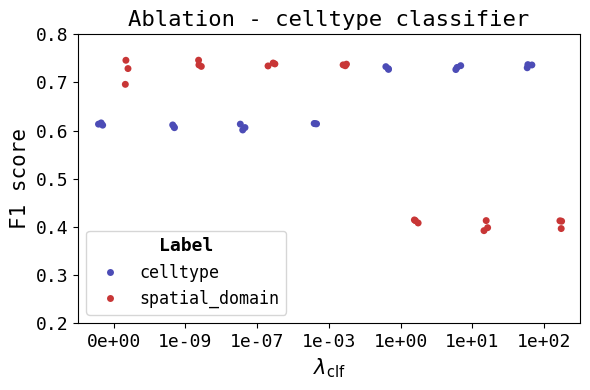

In [81]:
# Optional: nicer lambda labels
df["lambda_str"] = df["lambda"].map(lambda x: f"{x:.0e}")

plt.figure(figsize=(6, 4))

ax = sns.stripplot(
    data=df,
    x="lambda_str",
    y="score",
    hue="label",
    palette={
        "celltype": "#4C4CB6",
        "spatial_domain": "#C83636"
    },
    dodge=True,   # separates the two labels side-by-side
    jitter=True   # small horizontal jitter so points don’t overlap
)
# ---- fix y-axis range ----
ax.set_ylim(0.2, 0.8)

# ---- increase tick label font sizes ----
ax.tick_params(axis='x', labelsize=13)
ax.tick_params(axis='y', labelsize=13)

plt.xlabel(r"$\lambda_{\text{clf}}$", fontsize=15)
plt.ylabel("F1 score", fontsize=15)
plt.title("Ablation - celltype classifier", fontsize=16)
# Increase font size of legend title and labels
plt.legend(title="Label", title_fontsize=13, fontsize=12, loc='lower left').get_title().set_fontweight("bold")


plt.savefig("../figures/ablation_lambda_clf.svg", bbox_inches="tight")
plt.tight_layout()
plt.show()

# 2. Discriminator

## Train

In [43]:
lambda_ds = lambda_ys

In [ ]:
for lambda_ in tqdm(lambda_ds, desc="Training (lambda_d)"):
    model_args["classifier_lambda"] = 1e-7
    # Add split info
    train_args['datasplitter_kwargs'] = {
                "external_indexing": [train_idx, val_idx, test_idx],
                }
    for seed in seeds:
        set_seed(seed)
        model_args["discriminator_lambda"] = lambda_
        model = CellinaModel(adata, **model_args)
        model.train(**train_args, plan_kwargs=plan_kwargs)
        model.save(f"{base_path}/trained/lambda_d_{lambda_}_seed_{seed}", overwrite=True)

## Eval

In [44]:
df_lambda_d = evaluate_models(
    adata,
    seeds,
    lambda_type="lambda_d",
    lambda_values=lambda_ds,
    target_col=domains_key,
    root_dir=f"{base_path}/trained",
    batch_size=batch_size,
)

Evaluating (lambda_d):   0%|          | 0/7 [00:00<?, ?it/s]Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.


INFO     File /data2/a330d/data/cellina-reproducibility/ablations/trained/lambda_d_0_seed_0/model.pt already       
         downloaded                                                                                                


/data/a330d/miniforge3/envs/cellina-graph/lib/python3.10/site-packages/scvi/data/fields/_layer_field.py:115: UserWarning: Training will be faster when sparse matrix is formatted as CSR. It is safe to cast before model initialization.
  _verify_and_correct_data_format(adata, self.attr_name, self.attr_key)


INFO     cellina: The Cellina model has been initialized                                                           


Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.


...

Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.


INFO     File /data2/a330d/data/cellina-reproducibility/ablations/trained/lambda_d_100_seed_2/model.pt already     
         downloaded                                                                                                


/data/a330d/miniforge3/envs/cellina-graph/lib/python3.10/site-packages/scvi/data/fields/_layer_field.py:115: UserWarning: Training will be faster when sparse matrix is formatted as CSR. It is safe to cast before model initialization.
  _verify_and_correct_data_format(adata, self.attr_name, self.attr_key)


INFO     cellina: The Cellina model has been initialized with adversarial domain forgetting                        


Evaluating (lambda_d): 100%|██████████| 7/7 [06:33<00:00, 56.27s/it]


In [45]:
df = df_lambda_d
df['label'] = 'spatial_domain'
df.to_csv(f"../results/ablation_lambda_disc.csv", index=False)

In [63]:
df = pd.read_csv("../results/ablation_lambda_disc.csv")

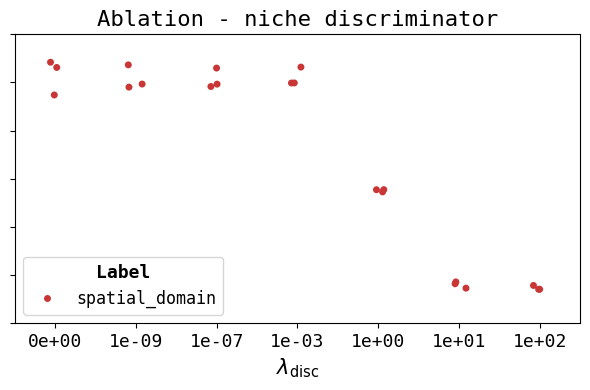

In [79]:
# Optional: nicer lambda labels
df["lambda_str"] = df["lambda"].map(lambda x: f"{x:.0e}")

plt.figure(figsize=(6, 4))

ax = sns.stripplot(
    data=df,
    x="lambda_str",
    y="score",
    hue="label",
    palette={
        "celltype": "#4C4CB6",
        "spatial_domain": "#C83636"
    },
    dodge=True,   # separates the two labels side-by-side
    jitter=True   # small horizontal jitter so points don’t overlap
)

# ---- fix y-axis range ----
ax.set_ylim(0.2, 0.8)

# ---- increase tick label font sizes ----
ax.tick_params(axis='x', labelsize=13)
ax.tick_params(axis='y', labelsize=13)

# Remove y label and y tick labels
ax.set_ylabel("")
ax.set_yticklabels([])

plt.xlabel(r"$\lambda_{\text{disc}}$", fontsize=15)
#plt.ylabel("F1 score", fontsize=15)
plt.title("Ablation - niche discriminator", fontsize=16)
# Increase font size of legend title and labels
plt.legend(title="Label", title_fontsize=13, fontsize=12, loc='lower left').get_title().set_fontweight("bold")

plt.savefig("../figures/ablation_lambda_disc.svg", bbox_inches="tight")
plt.tight_layout()
plt.show()

# 3. Edge predictor

## Train

In [ ]:
alpha_edge = [0., 0.01, 5, 1000, 1000000]

In [ ]:
for alpha in tqdm(alpha_edge, desc="Training (alpha_edge)"):
    for seed in seeds:
        set_seed(seed)
        model = CellinaModel(
            adata_train, n_latent=64, 
            classifier_lambda=1e2, 
            discriminator_lambda=1e2,
            link_prediction_weight=alpha,
        )
        model.train(
            max_epochs=epochs,
            check_val_every_n_epoch=1,
            early_stopping=True,
            early_stopping_patience=25,
            early_stopping_monitor="validation_loss",  # NOTE: z/e kl + reconstruction
            train_size=0.9,
            validation_size=0.1,
            plan_kwargs={
                "lr": 0.0001,
                "weight_decay": 0.0001,
            },
            enable_checkpointing=True,
            batch_size=2048,
            devices=[1],
        )

        model.save(f"{base_path}/trained/alpha_edge_{alpha}_seed_{seed}", overwrite=True)

## Eval

In [ ]:
df_alpha_edge = evaluate_models(
    adata,
    seeds,
    alpha_type="alpha_edge",
    alpha_values=alpha_edge,
    target_col="BEST_RESPONSE_BY_SCAN",
    latent_key='s',
    root_dir=f"{base_path}/trained",
)

In [ ]:
plot_results(df_alpha_edge, alpha_type="alpha_edge", target_col='BEST_RESPONSE_BY_SCAN')

# Evaluate Marginal LL via Importance Sampling to see holdout data fit

In [ ]:
results = {"lambda_y": {}, "lambda_d": {}}
for lambda_type in results.keys():
    for lambda_ in lambda_ys:
        res_by_seed = []
        for seed in seeds:
            set_seed(seed)
            save_path = f"{base_path}/trained/{lambda_type}_{lambda_}_seed_{seed}"

            model = CellinaModel.load(save_path, adata)

            mll = model.get_marginal_ll(adata=adata[adata.obs['is_holdout']], 
                                        n_mc_samples=n_mc_samples,
                                        return_mean=True)
            res_by_seed.append(mll)
        results[lambda_type][lambda_] = res_by_seed

In [23]:
with open(f"../results/mll_gridsearch_melanoma_{split}.pkl", "wb") as f:
    pickle.dump(results, f)

## Plot

In [24]:
with open(f"../results/mll_gridsearch_melanoma_{split}.pkl", "rb") as f:
    results = pickle.load(f)

In [25]:
def plot_mll_boxplot(results, title="Marginal LL on holdout (Higher is better)"):
    lambdas = list(results.keys())
    data = [results[c] for c in lambdas]

    fig, ax = plt.subplots(figsize=(6, 4))

    bp = ax.boxplot(
        data,
        patch_artist=True,   # allows facecolor
        labels=lambdas,
        medianprops=dict(color='black', linewidth=2)
    )


    # Optional: jittered points overlaid on the boxes
    for i, cond in enumerate(lambdas):
        y = np.array(results[cond])
        x = np.random.normal(i+1, 0.04, size=len(y))   # jitter for visibility
        ax.scatter(x, y, color="black", s=30, zorder=3)

    ax.set_xlabel("$\lambda$ strength")
    ax.set_ylabel("Marginal LL")
    ax.set_title(title)

    plt.tight_layout()
    plt.show()

/tmp/ipykernel_3395819/3261663957.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


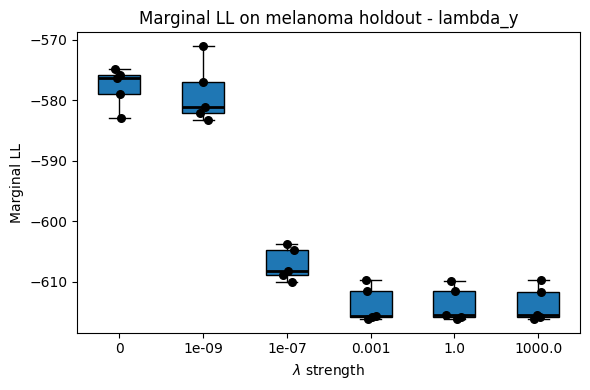

In [26]:
# melanoma
plot_mll_boxplot(results['lambda_y'], title="Marginal LL on melanoma holdout - lambda_y")

/tmp/ipykernel_1201087/3261663957.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


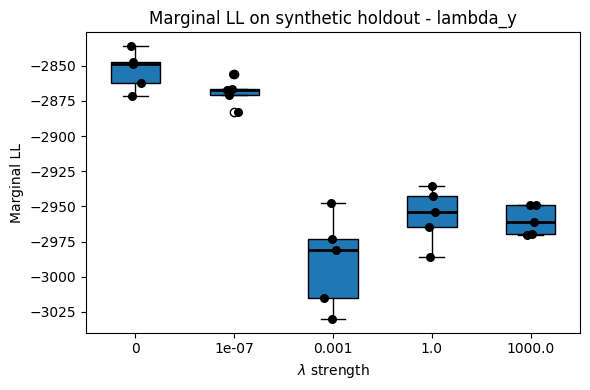

In [ ]:
# sim
plot_mll_boxplot(results['lambda_y'], title="Marginal LL on synthetic holdout - lambda_y")

/tmp/ipykernel_3395819/3261663957.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


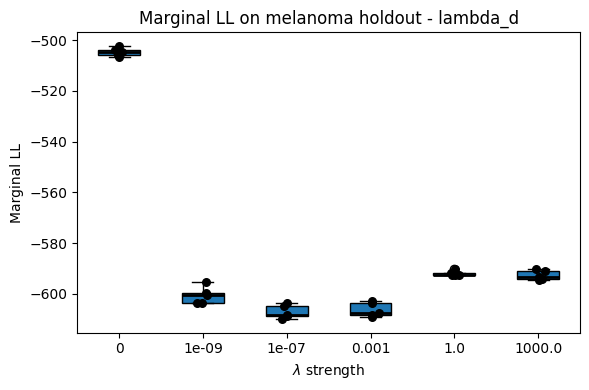

In [27]:
# melanoma
plot_mll_boxplot(results['lambda_d'], title="Marginal LL on melanoma holdout - lambda_d")

/tmp/ipykernel_1201087/3261663957.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


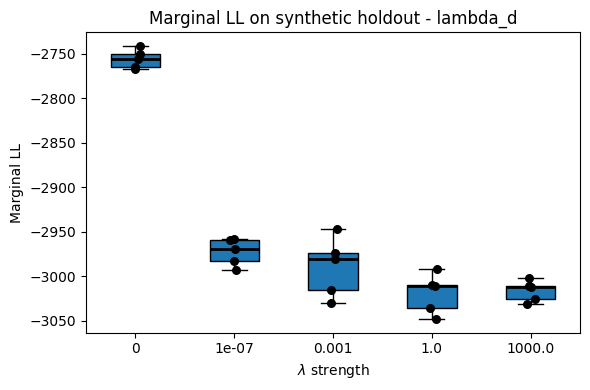

In [ ]:
# sim
plot_mll_boxplot(results['lambda_d'], title="Marginal LL on synthetic holdout - lambda_d")